# Sampling comparison and SHAP — low-review classification

Zaghloul et al. (2024) retrain every classifier under `RandomOverSampler`, `SMOTE` and `ADASYN` (their Experiment 4)
and report accuracy, weighted precision / recall / F1 and AUC-ROC. This notebook repeats that study on our protocol,
adds the two strategies the brief names (no adjustment, class weights) and the imbalance-aware metrics the brief asks
for (PR-AUC, balanced accuracy, Brier), then explains the final model with SHAP.

* **Grid**: 4 models (tuned logistic, decision tree, random forest, CatBoost; configurations from
  `outputs/selected_models.json`) × 5 strategies (`none`, `class_weight`, `random_oversampler`, `smote`, `adasyn`) = 20 fits.
  No re-tuning: the question is what the imbalance strategy does to a fixed model.
* Resampling runs **inside** an imbalanced-learn pipeline after the preprocessor, on training rows only.
  CatBoost uses the forest's numeric matrix here (SMOTE / ADASYN cannot interpolate string categories); its native
  categorical result is the ladder row in `model_comparison.csv`.
* Thresholds are chosen on validation (F1) and frozen; the test set is scored once per cell.
* **SHAP**: TreeExplainer on the final forest (and CatBoost as a cross-check), with one-hot and indicator columns
  folded back onto the original features; the exact linear SHAP of the logistic model as a sanity check.

Set `QUICK = True` for a dry run (small forests / CatBoost); the report numbers come from `QUICK = False`.

In [1]:
from pathlib import Path
import sys, warnings
_c = Path.cwd()
ROOT = next((p for p in [_c, *_c.parents, _c / "Phase 2" / "classification", _c / "classification"]
             if (p / "config" / "problem_spec.json").is_file() and (p / "src" / "paths.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository root, Phase 2, or Phase 2/classification.")
sys.path.insert(0, str(ROOT / "src"))
import paths  # adds Phase 2/src (regression package) to sys.path as well
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import clf_config as config, clf_features as features, clf_split as split, clf_pipelines as pipelines, clf_evaluate as evaluate
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
ACCENT, GREY, RED = "#2563eb", "#9ca3af", "#dc2626"
for d in (config.FIGURES_DIR, config.RESULTS_DIR, config.PROCESSED_DIR, config.MODELS_DIR): d.mkdir(parents=True, exist_ok=True)
print("package root:", ROOT)
import joblib, json, time
from sklearn.base import clone
import clf_sampling as sampling, clf_explain as explain

QUICK = True
PROBLEM = "p2"
OUT = config.ROOT / "outputs"
best = json.load(open(OUT / "selected_models.json"))
print("configurations from baseline_variant_review | final model:", best["final_model"], "| quick:", best["quick_mode"])

package root: /home/claude/mock/Phase 2/classification
configurations from baseline_variant_review | final model: B_rf | quick: True


## 1. Data

In [2]:
df = features.load_feature_table()
cohort = features.cohort(df, PROBLEM)
S = split.split_frame(cohort)
X_tr, y_tr = split.xy(S["train"], PROBLEM); X_va, y_va = split.xy(S["validation"], PROBLEM); X_te, y_te = split.xy(S["test"], PROBLEM)
print({k: v.shape for k, v in S.items()}, "| positive rate", round(y_tr.mean(), 4))

{'train': (52482, 78), 'validation': (13121, 78), 'test': (32313, 78)} | positive rate 0.1417


## 2. The 20 fits

Tuned parameters are taken from the ladder; the CatBoost iteration count is the early-stopped one when it was retained.
`fit_seconds` and `train_rows_after_sampling` are recorded because the paper's main finding about resampling is cost.

In [3]:
params = {m: dict(best["best_params"].get(m, {})) for m in sampling.MODELS}
if QUICK:
    params["B_rf"]["model__n_estimators"] = 100; params["B_catboost"]["model__iterations"] = 150
rows, fitted, proba = [], {}, {}
for model in sampling.MODELS:
    for strategy in sampling.STRATEGIES:
        t0 = time.time()
        pipe = sampling.build(model, strategy, PROBLEM, params[model]).fit(X_tr, y_tr)
        p_va, p_te = pipe.predict_proba(X_va)[:, 1], pipe.predict_proba(X_te)[:, 1]
        thr = evaluate.best_threshold(y_va, p_va)
        mv, mt = evaluate.classification_metrics(y_va, p_va, thr), evaluate.classification_metrics(y_te, p_te, thr)
        n_after = len(y_tr)
        if strategy not in ("none", "class_weight"):
            n_after = len(pipe.named_steps["sample"].fit_resample(pipe.named_steps["pre"].transform(X_tr), y_tr)[1])
        rows.append({"model": model, "strategy": strategy, "fit_seconds": round(time.time() - t0, 1),
                     "train_rows_after_sampling": n_after, "threshold": thr,
                     **{f"val_{k}": v for k, v in mv.items() if k != "threshold"},
                     **{f"test_{k}": v for k, v in mt.items() if k != "threshold"}})
        fitted[(model, strategy)], proba[(model, strategy)] = pipe, (p_va, p_te)
        print(f"{model:15s} {strategy:19s} val PR-AUC {mv['pr_auc']:.3f}  test PR-AUC {mt['pr_auc']:.3f}  "
              f"ROC {mt['roc_auc']:.3f}  Brier {mt['brier']:.3f}  rows {n_after:6d}  {time.time()-t0:.0f}s")
res = pd.DataFrame(rows).set_index(["model", "strategy"])
res.to_csv(OUT / "tables/sampling_comparison.csv")

A_linear_tuned  none                val PR-AUC 0.490  test PR-AUC 0.490  ROC 0.784  Brier 0.093  rows  52482  3s


A_linear_tuned  class_weight        val PR-AUC 0.484  test PR-AUC 0.486  ROC 0.787  Brier 0.165  rows  52482  4s


A_linear_tuned  random_oversampler  val PR-AUC 0.485  test PR-AUC 0.486  ROC 0.787  Brier 0.165  rows  90092  5s


A_linear_tuned  smote               val PR-AUC 0.484  test PR-AUC 0.483  ROC 0.783  Brier 0.166  rows  90092  6s


A_linear_tuned  adasyn              val PR-AUC 0.473  test PR-AUC 0.471  ROC 0.780  Brier 0.198  rows  91190  9s


...

B_catboost      none                val PR-AUC 0.510  test PR-AUC 0.506  ROC 0.788  Brier 0.092  rows  52482  3s


B_catboost      class_weight        val PR-AUC 0.499  test PR-AUC 0.498  ROC 0.787  Brier 0.163  rows  52482  3s


B_catboost      random_oversampler  val PR-AUC 0.501  test PR-AUC 0.502  ROC 0.788  Brier 0.162  rows  90092  4s


B_catboost      smote               val PR-AUC 0.494  test PR-AUC 0.495  ROC 0.783  Brier 0.095  rows  90092  7s


B_catboost      adasyn              val PR-AUC 0.495  test PR-AUC 0.494  ROC 0.783  Brier 0.095  rows  90401  10s


## 3. Results

Two views of the same table: (a) the imbalance-aware metrics the brief asks for, (b) the paper's metrics
(accuracy and class-size-weighted precision / recall / F1), which are dominated by the 86% majority class and
therefore barely move between strategies. The best strategy per model by **validation** PR-AUC is marked.

In [4]:
cols_a = ["val_pr_auc", "test_pr_auc", "test_roc_auc", "test_balanced_acc", "test_brier", "test_precision", "test_recall", "test_f1", "test_flag_rate", "threshold", "fit_seconds"]
tab_a = res[cols_a].round(3)
best_by_model = res.groupby(level=0).val_pr_auc.idxmax()
tab_a["best_on_validation"] = ["*" if idx in set(best_by_model) else "" for idx in res.index]
display(tab_a)
cols_b = ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted", "test_roc_auc", "train_rows_after_sampling"]
res[cols_b].round(3)

val_pr_auc  test_pr_auc  test_roc_auc  test_balanced_acc  test_brier  test_precision  test_recall  test_f1  test_flag_rate  \
model          strategy                                                                                                                                         
A_linear_tuned none                     0.490        0.490         0.784              0.714       0.093           0.552        0.494    0.521           0.127   
               class_weight             0.484        0.486         0.787              0.716       0.165           0.537        0.504    0.520           0.133   
               random_oversampler       0.485        0.486         0.787              0.716       0.165           0.537        0.504    0.520           0.133   
               smote                    0.484        0.483         0.783              0.713       0.166           0.551        0.492    0.520           0.126   
               adasyn                   0.473        0.471         0.780              0.714       0.198           0.520        0.505    0.512           0.138   
B_tree_base    none                     0.500        0.483         0.771              0.706       0.095           0.573        0.470    0.516           0.116   
               class_weight             0.493        0.482         0.772              0.708       0.169           0.549        0.481    0.513           0.124   
               random_oversampler       0.471        0.461         0.764              0.696       0.168           0.531        0.459    0.492           0.122   
               smote                    0.450        0.451         0.758              0.703       0.106           0.521        0.479    0.499           0.130   
               adasyn                   0.454        0.459         0.764              0.702       0.103           0.561        0.463    0.507           0.117   
B_rf           none                     0.518        0.510         0.791              0.718       0.092           0.546        0.504    0.524           0.131   
               class_weight             0.515        0.508         0.791              0.714       0.147           0.553        0.494    0.522           0.127   
               random_oversampler       0.507        0.506         0.789              0.715       0.147           0.553        0.497    0.524           0.127   
               smote                    0.497        0.497         0.782              0.713       0.098           0.537        0.496    0.516           0.131   
               adasyn                   0.494        0.495         0.780              0.705       0.099           0.568        0.470    0.514           0.117   
B_catboost     none                     0.510        0.506         0.788              0.721       0.092           0.534        0.517    0.525           0.137   
               class_weight             0.499        0.498         0.787              0.718       0.163           0.525        0.513    0.519           0.138   
               random_oversampler       0.501        0.502         0.788              0.722       0.162           0.511        0.528    0.519           0.146   
               smote                    0.494        0.495         0.783              0.711       0.095           0.552        0.488    0.518           0.125   
               adasyn                   0.495        0.494         0.783              0.702       0.095           0.579        0.459    0.512           0.112   

                                   threshold  fit_seconds best_on_validation  
model          strategy                                                       
A_linear_tuned none                    0.253          2.8                  *  
               class_weight            0.662          3.8                     
               random_oversampler      0.661          4.7                     
               smote                   0.682          5.8                     
               ada

test_accuracy  test_precision_weighted  test_recall_weighted  test_f1_weighted  test_roc_auc  train_rows_after_sampling
model          strategy                                                                                                                                   
A_linear_tuned none                        0.871                    0.866                 0.871             0.868         0.784                      52482
               class_weight                0.868                    0.865                 0.868             0.866         0.787                      52482
               random_oversampler          0.868                    0.865                 0.868             0.866         0.787                      90092
               smote                       0.871                    0.866                 0.871             0.868         0.783                      90092
               adasyn                      0.864                    0.862                 0.864             0.863         0.780                      91190
B_tree_base    none                        0.875                    0.867                 0.875             0.870         0.771                      52482
               class_weight                0.871                    0.864                 0.871             0.867         0.772                      52482
               random_oversampler          0.866                    0.859                 0.866             0.862         0.764                      90092
               smote                       0.864                    0.859                 0.864             0.861         0.758                      90092
               adasyn                      0.872                    0.864                 0.872             0.867         0.764                      90401
B_rf           none                        0.870                    0.866                 0.870             0.868         0.791                      52482
               class_weight                0.872                    0.866                 0.872             0.869         0.791                      52482
               random_oversampler          0.872                    0.867                 0.872             0.869         0.789                      90092
               smote                       0.868                    0.864                 0.868             0.866         0.782                      90092
               adasyn                      0.874                    0.866                 0.874             0.869         0.780                      90401
B_catboost     none                        0.868                    0.866                 0.868             0.867         0.788                      52482
               class_weight                0.865                    0.864                 0.865             0.865         0.787                      52482
               random_oversampler          0.862                    0.863                 0.862             0.862         0.788                      90092
               smote                       0.871                    0.865                 0.871             0.868         0.783                      90092
               adasyn                      0.876                    0.866                 0.876             0.870         0.783                      90401

In [5]:
# strategy effect relative to 'none', per model (test PR-AUC and Brier)
delta = res.test_pr_auc.unstack("strategy")[sampling.STRATEGIES]
delta_brier = res.test_brier.unstack("strategy")[sampling.STRATEGIES]
print("test PR-AUC by strategy"); display(delta.round(3))
print("test Brier by strategy (lower is better)"); display(delta_brier.round(3))

test PR-AUC by strategy


strategy,none,class_weight,random_oversampler,smote,adasyn
model,,,,,
A_linear_tuned,0.490,0.486,0.486,0.483,0.471
B_catboost,0.506,0.498,0.502,0.495,0.494
B_rf,0.510,0.508,0.506,0.497,0.495
B_tree_base,0.483,0.482,0.461,0.451,0.459


test Brier by strategy (lower is better)


strategy,none,class_weight,random_oversampler,smote,adasyn
model,,,,,
A_linear_tuned,0.093,0.165,0.165,0.166,0.198
B_catboost,0.092,0.163,0.162,0.095,0.095
B_rf,0.092,0.147,0.147,0.098,0.099
B_tree_base,0.095,0.169,0.168,0.106,0.103


## 4. Figure (report Figure 5)

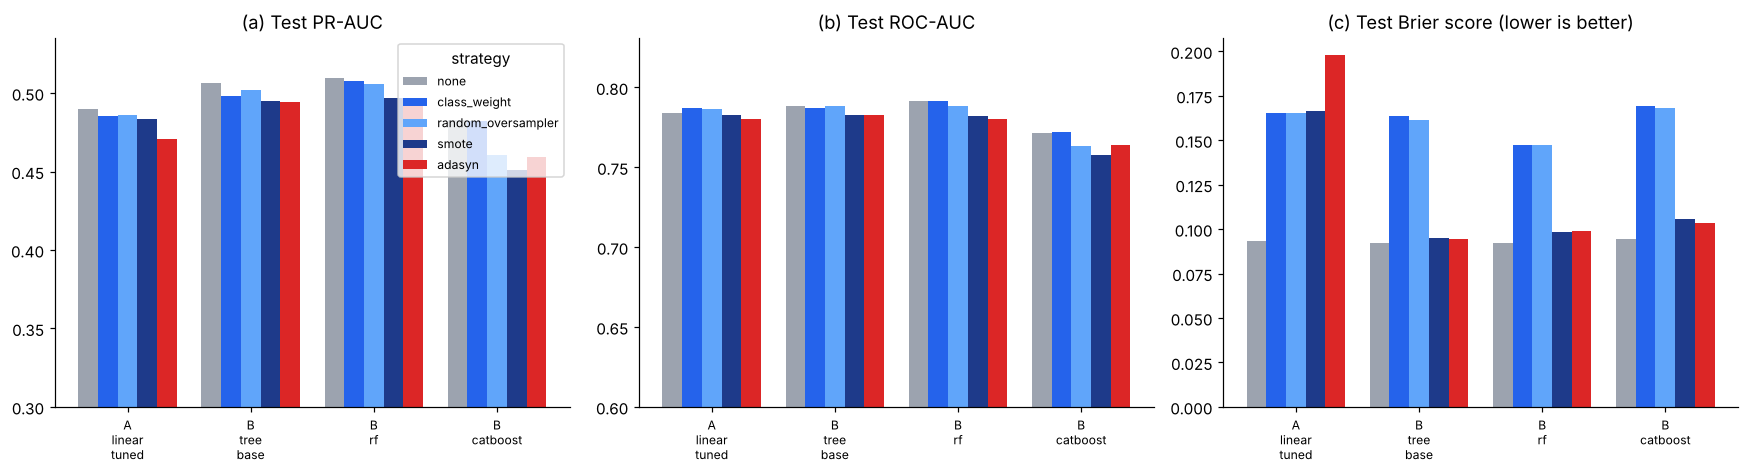

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
pal = dict(zip(sampling.STRATEGIES, [GREY, ACCENT, "#60a5fa", "#1e3a8a", RED]))
w = 0.16; x = np.arange(len(sampling.MODELS))
for j, strat in enumerate(sampling.STRATEGIES):
    ax[0].bar(x + (j - 2) * w, delta[strat].values, w, color=pal[strat], label=strat)
    ax[1].bar(x + (j - 2) * w, res.test_roc_auc.unstack("strategy")[strat].values, w, color=pal[strat])
    ax[2].bar(x + (j - 2) * w, delta_brier[strat].values, w, color=pal[strat])
for a, t in zip(ax, ("(a) Test PR-AUC", "(b) Test ROC-AUC", "(c) Test Brier score (lower is better)")):
    a.set_xticks(x); a.set_xticklabels([m.replace("_", "\n") for m in sampling.MODELS], fontsize=8); a.set_title(t)
ax[0].axhline(y_te.mean(), ls="--", color=GREY, lw=1); ax[0].set_ylim(0.3, None); ax[1].set_ylim(0.6, None)
ax[0].legend(fontsize=8, title="strategy")
plt.tight_layout(); fig.savefig(OUT / "figures/05_sampling_comparison.png", bbox_inches="tight")

## 5. SHAP on the final model

`shap.TreeExplainer` on the forest under its retained strategy (positive-class contributions, 1,500 validation rows).
One-hot and missing-indicator columns are summed back onto their original feature for the bar chart so it is
comparable with the permutation importance in `baseline_variant_review`. The beeswarm keeps the transformer columns
so the direction of each effect is visible.

In [7]:
import shap
FINAL = best["final_model"] if best["final_model"] in sampling.MODELS else "B_rf"
FINAL_STRATEGY = best_by_model[FINAL][1]
pipe = fitted[(FINAL, FINAL_STRATEGY)]
print("explaining", FINAL, "under", FINAL_STRATEGY)
t0 = time.time()
sv, M, names, base_value, idx = explain.shap_tree(pipe, X_va, max_rows=600 if QUICK else 1500)
print(f"SHAP values {sv.shape} in {time.time()-t0:.0f}s; base value {base_value:.3f}")
grouped = explain.group_by_feature(sv, names, config.features_for(PROBLEM))
grouped.to_csv(OUT / "tables/shap_importance.csv", index=False)
grouped.head(15)

explaining B_rf under none


SHAP values (600, 120) in 8s; base value 0.142


,feature,mean_abs_shap,columns
0,n_items,0.023608,1
1,wd_delivery_time_delta,0.023237,2
2,delivery_time_delta,0.016973,2
3,delivery_vs_seller_prior,0.013380,2
4,wd_actual_delivery_time,0.011859,2
5,actual_delivery_time,0.011538,2
6,seller_id_enc,0.010203,1
7,is_delivered,0.009530,1
8,promised_days,0.005795,1
9,carrier_transit_days,0.004997,2


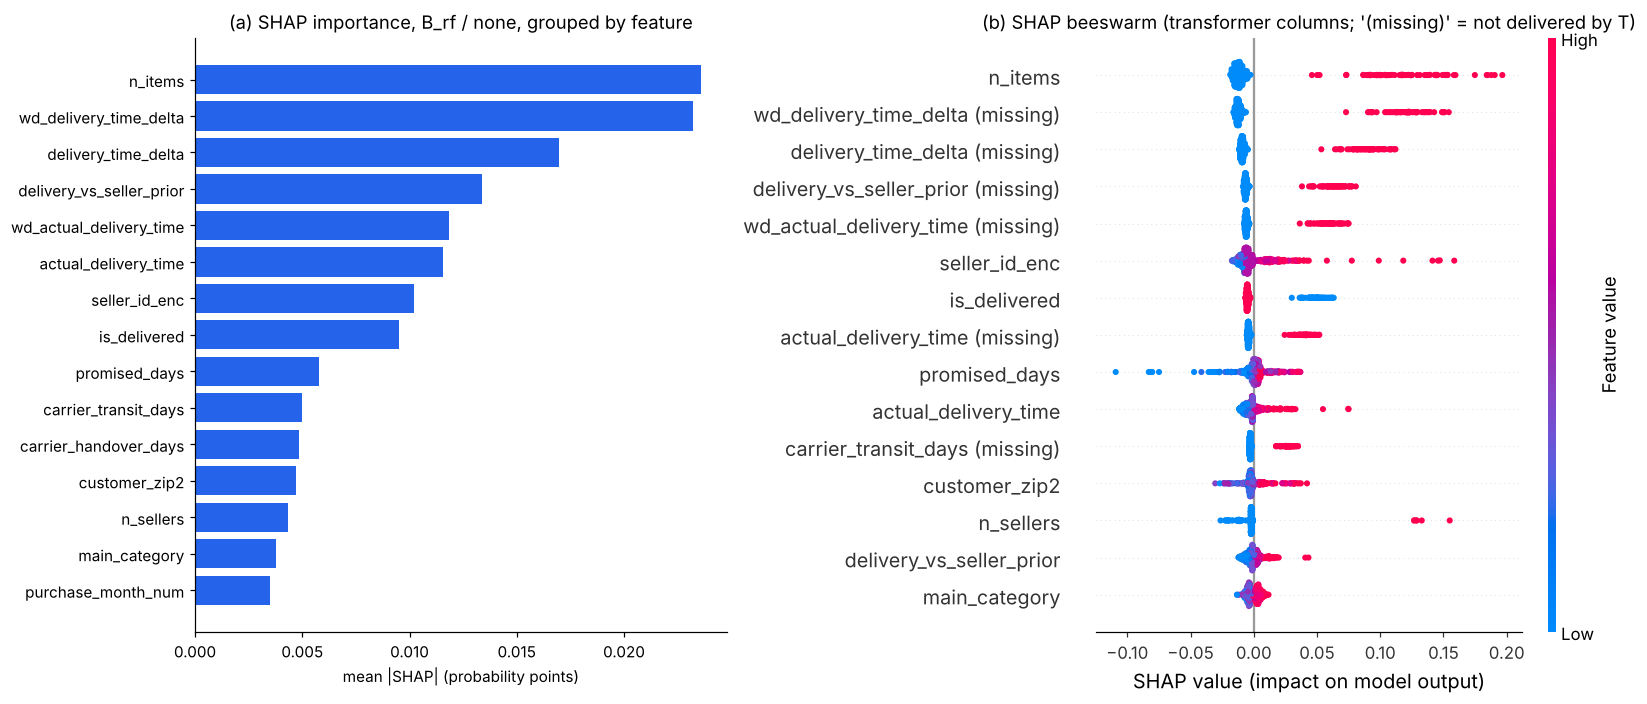

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
top = grouped.head(15)
ax[0].barh(top.feature[::-1], top.mean_abs_shap[::-1], color=ACCENT)
ax[0].set_xlabel("mean |SHAP| (probability points)"); ax[0].set_title(f"(a) SHAP importance, {FINAL} / {FINAL_STRATEGY}, grouped by feature")
plt.sca(ax[1])
short = [explain.original_feature(n, config.features_for(PROBLEM), keep_indicators=True) if n.startswith(("num__", "skew__", "high__")) else n.split("__", 1)[-1] for n in names]
shap.summary_plot(sv, M, feature_names=short, max_display=15, show=False, plot_size=None)
ax[1].set_title("(b) SHAP beeswarm (transformer columns; '(missing)' = not delivered by T)")
plt.tight_layout(); fig.savefig(OUT / "figures/06_shap_summary.png", bbox_inches="tight")

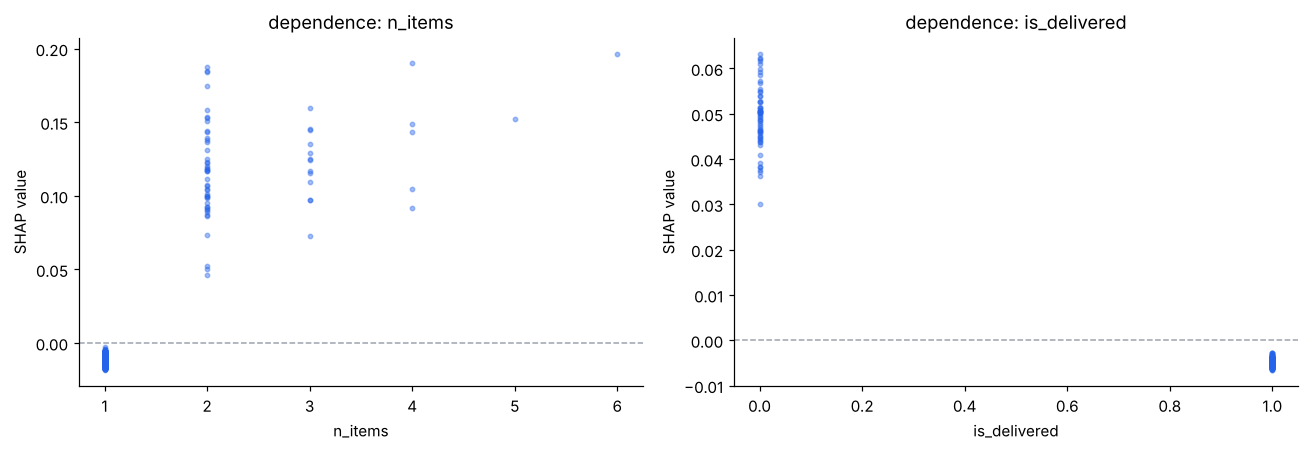

In [9]:
# dependence of the two strongest numeric effects
num_cols = [n for n in names if n.startswith("num__") and "missingindicator" not in n]
top_num = sorted(num_cols, key=lambda n: -np.abs(sv[:, names.index(n)]).mean())[:2]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, n in zip(ax, top_num):
    j = names.index(n); ok = ~np.isnan(M[:, j])
    a.scatter(M[ok, j], sv[ok, j], s=8, alpha=0.4, color=ACCENT)
    a.axhline(0, ls="--", color=GREY, lw=1); a.set_xlabel(n.split("__", 1)[1]); a.set_ylabel("SHAP value")
    a.set_title(f"dependence: {n.split('__', 1)[1]}")
plt.tight_layout(); fig.savefig(OUT / "figures/07_shap_dependence.png", bbox_inches="tight")

### Cross-checks: CatBoost SHAP and exact linear SHAP

If the three model families agree on the top features, the ranking is a property of the data rather than of one
algorithm. Units differ (the forest explains probabilities, CatBoost and the logistic model explain log-odds), so
only the **ranks** are compared: Spearman correlation of the grouped mean |SHAP| is printed.

In [10]:
cb_sv, cb_M, cb_names, _, _ = explain.shap_tree(fitted[("B_catboost", best_by_model["B_catboost"][1])], X_va, max_rows=600 if QUICK else 1500)
cb_grouped = explain.group_by_feature(cb_sv, cb_names, config.features_for(PROBLEM))
lin_sv, lin_M, lin_names, _, _ = explain.shap_linear(fitted[("A_linear_tuned", best_by_model["A_linear_tuned"][1])], X_va, max_rows=600 if QUICK else 1500)
lin_grouped = explain.group_by_feature(lin_sv, lin_names, config.features_for(PROBLEM))
cmp = (grouped.set_index("feature").mean_abs_shap.rename("rf")
       .to_frame().join(cb_grouped.set_index("feature").mean_abs_shap.rename("catboost"))
       .join(lin_grouped.set_index("feature").mean_abs_shap.rename("logistic")))
cmp = cmp.fillna(0).sort_values("rf", ascending=False)
cmp.to_csv(OUT / "tables/shap_cross_model.csv")
print("Spearman rank correlation of grouped mean |SHAP|:"); display(cmp.rank().corr(method="spearman").round(2))
cmp.head(12).round(4)

Spearman rank correlation of grouped mean |SHAP|:


,rf,catboost,logistic
rf,1.00,0.87,0.41
catboost,0.87,1.00,0.54
logistic,0.41,0.54,1.00


,rf,catboost,logistic
feature,,,
n_items,0.0236,0.1636,0.0190
wd_delivery_time_delta,0.0232,0.1092,0.1435
delivery_time_delta,0.0170,0.0493,0.2002
delivery_vs_seller_prior,0.0134,0.0403,0.0934
wd_actual_delivery_time,0.0119,0.0525,0.1375
actual_delivery_time,0.0115,0.0875,0.0719
seller_id_enc,0.0102,0.0867,0.0992
is_delivered,0.0095,0.1078,0.0710
promised_days,0.0058,0.0545,0.3845


## 6. Save

In [11]:
summary = {"strategies": sampling.STRATEGIES, "models": sampling.MODELS,
           "best_strategy_by_model_on_validation": {m: s for m, s in best_by_model.values},
           "final_model": FINAL, "final_strategy": FINAL_STRATEGY, "quick_mode": QUICK,
           "test_pr_auc": {f"{m}/{s}": round(v, 4) for (m, s), v in res.test_pr_auc.items()},
           "shap_top10": grouped.head(10).feature.tolist()}
json.dump(summary, open(OUT / "sampling_summary.json", "w"), indent=2)
joblib.dump({"pipeline": pipe, "model": FINAL, "strategy": FINAL_STRATEGY, "threshold": float(res.loc[(FINAL, FINAL_STRATEGY), "threshold"])},
            config.MODELS_DIR / "sampling_final.joblib")
print(json.dumps({k: summary[k] for k in ("best_strategy_by_model_on_validation", "final_model", "final_strategy", "shap_top10")}, indent=2))

{
  "best_strategy_by_model_on_validation": {
    "A_linear_tuned": "none",
    "B_catboost": "none",
    "B_rf": "none",
    "B_tree_base": "none"
  },
  "final_model": "B_rf",
  "final_strategy": "none",
  "shap_top10": [
    "n_items",
    "wd_delivery_time_delta",
    "delivery_time_delta",
    "delivery_vs_seller_prior",
    "wd_actual_delivery_time",
    "actual_delivery_time",
    "seller_id_enc",
    "is_delivered",
    "promised_days",
    "carrier_transit_days"
  ]
}


## 7. Reading the results

* **Ranking vs scale.** Compare the PR-AUC and ROC-AUC rows across strategies with the Brier rows: on this target the
  strategies move the probability scale (Brier, flag rate at the default cut) far more than the ranking. The paper's
  accuracy / weighted-F1 gains after oversampling are small for the same reason.
* **Cost.** `train_rows_after_sampling` roughly doubles under oversampling, and `fit_seconds` with it; ADASYN adds the
  most synthetic rows in the hardest regions.
* **Which to retain.** The report should keep the ladder's class-weight choice unless a resampler wins on validation
  PR-AUC by the same ≥ 1% relative rule used elsewhere, and should say so in Section 6.3.
* **SHAP vs permutation importance.** Both are on the validation set; if the top-5 lists agree the interpretation
  section can quote either. Grouped SHAP sums a feature's one-hot and missing-indicator columns per row before taking
  the mean absolute value, so high-cardinality categoricals are not penalised for being spread across columns and the
  "not delivered by T" effect is attributed to the delivery-as-of-T features it belongs to rather than appearing once
  per indicator.